In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import (
    FIGURES_PATH,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    RANDOM_SENS_PROBS_LIST,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index
from fair_dynamic_pricing_with_rl.utils.config import PRODUCT_LIST

In [2]:
PARAMETER_NAME_DICT = {
    "experiment_1": "random_action_prob",
    "experiment_2": "fairness_weight",
    "experiment_3": "random_sens_prob"
}

In [16]:
def calculate_final_results_table(experiment_name: str,
                                  experiment_parameter_mapping:dict = PARAMETER_NAME_DICT):
    """Reads and amends results table with additional metrics on fairness.
    """
    results = pd.read_csv(f"../output/{experiment_name}/results.csv")

    # query main parameter name from mapping
    parameter_name = experiment_parameter_mapping[experiment_name]

    # calculate absolute difference and this relative to pure PPO
    results["abs_diff (USD)"] = np.abs(results["nonsnap_price"] - results["snap_price"])
    ppo_abs_diff = results.loc[results[parameter_name]==0.0,"abs_diff (USD)"].to_numpy()
    results["abs_diff (% of vanilla-PPO)"] = (results["abs_diff (USD)"] / ppo_abs_diff)*100
    # the negative is taken so that higher is better
    results["abs_diff_perc_fairness"] = -(results["abs_diff (% of vanilla-PPO)"] - 100)

    # calculate revenue difference compared to pure PPO
    ppo_revenue = results.loc[results[parameter_name]==0.0,"mean_episode_revenue"].to_numpy()
    results["abs_diff_perc_revenue"] = (results["mean_episode_revenue"] / ppo_revenue - 1)*100

    # add column with experiment name
    results["experiment"] = experiment_name

    # return result table
    return results

# Experiment 1

In [17]:
calculate_final_results_table("experiment_1")

,mean_episode_revenue,jains_index,random_action_prob,nonsnap_price,snap_price,abs_diff (USD),abs_diff (% of vanilla-PPO),abs_diff_perc_fairness,abs_diff_perc_revenue,experiment
0,9944.110615,0.999986,0.000000,16.586586,16.463847,0.122739,100.000000,-0.000000,0.000000,experiment_1
1,7432.007857,0.999984,0.111111,16.159881,16.031368,0.128514,104.705116,-4.705116,-25.262217,experiment_1
2,6234.412375,0.999981,0.222222,15.906685,15.769335,0.137350,111.904350,-11.904350,-37.305480,experiment_1
3,5403.368747,0.999982,0.333333,15.657278,15.525910,0.131368,107.030176,-7.030176,-45.662624,experiment_1
4,4677.122458,0.999992,0.444444,15.465479,15.379423,0.086056,70.113351,29.886649,-52.965905,experiment_1
5,3222.220481,0.999990,0.555556,15.068998,14.975790,0.093207,75.939750,24.060250,-67.596695,experiment_1
6,2555.864505,0.999995,0.666667,14.815056,14.750685,0.064371,52.445743,47.554257,-74.297706,experiment_1
7,2022.275501,0.999999,0.777778,14.551205,14.523243,0.027962,22.782129,77.217871,-79.663586,experiment_1
8,1404.169498,0.999994,0.888889,14.303495,14.232620,0.070875,57.744600,42.255400,-85.879386,experiment_1
9,795.715151,1.000000,1.000000,13.996894,14.016380,0.019486,15.876200,84.123800,-91.998127,experiment_1


# Experiment 2

In [18]:
calculate_final_results_table("experiment_2")

,mean_episode_revenue,jains_index,fairness_weight,nonsnap_price,snap_price,abs_diff (USD),abs_diff (% of vanilla-PPO),abs_diff_perc_fairness,abs_diff_perc_revenue,experiment
0,6810.703819,0.999769,0.000000,16.799590,16.296130,0.503460,100.000000,-0.000000,0.000000,experiment_2
1,6792.535867,0.999830,0.111111,16.820277,16.387467,0.432810,85.967108,14.032892,-0.266756,experiment_2
2,6814.650443,0.999865,0.222222,16.798361,16.411922,0.386439,76.756594,23.243406,0.057947,experiment_2
3,6731.014626,0.999991,0.333333,16.776480,16.677048,0.099433,19.749831,80.250169,-1.170058,experiment_2
4,6706.163584,0.999995,0.444444,16.755631,16.684130,0.071501,14.201972,85.798028,-1.534940,experiment_2
5,6690.286094,0.999996,0.555556,16.769100,16.698900,0.070200,13.943511,86.056489,-1.768066,experiment_2
6,6659.592365,0.999999,0.666667,16.733279,16.698980,0.034299,6.812607,93.187393,-2.218735,experiment_2
7,6471.300004,0.999998,0.777778,16.631220,16.581222,0.049998,9.930779,90.069221,-4.983388,experiment_2
8,1142.885988,1.000000,0.888889,14.345292,14.341938,0.003355,0.666389,99.333611,-83.219268,experiment_2
9,651.317670,0.999998,1.000000,14.438061,14.401710,0.036351,7.220286,92.779714,-90.436852,experiment_2


# Experiment 3

In [19]:
experiment3_results = calculate_final_results_table("experiment_3")
experiment3_results

,mean_episode_revenue,jains_index,nonsnap_price,snap_price,random_sens_prob,abs_diff (USD),abs_diff (% of vanilla-PPO),abs_diff_perc_fairness,abs_diff_perc_revenue,experiment
0,9944.110615,0.999986,16.586586,16.463847,0.000000,0.122739,100.000000,-0.000000,0.000000,experiment_3
1,9513.097827,0.999995,16.538195,16.463922,0.111111,0.074272,60.512674,39.487326,-4.334352,experiment_3
2,9619.349326,0.999999,16.522864,16.488202,0.222222,0.034661,28.239859,71.760141,-3.265866,experiment_3
3,8279.551796,0.999999,16.330751,16.300175,0.333333,0.030576,24.911652,75.088348,-16.739142,experiment_3
4,8433.368705,1.000000,16.330710,16.326853,0.444444,0.003857,3.142854,96.857146,-15.192328,experiment_3
5,8376.963731,1.000000,16.336764,16.323187,0.555556,0.013576,11.061095,88.938905,-15.759548,experiment_3
6,9395.201373,1.000000,16.466360,16.444150,0.666667,0.022210,18.095345,81.904655,-5.519943,experiment_3
7,8386.288595,0.999998,16.356488,16.312177,0.777778,0.044310,36.101068,63.898932,-15.665775,experiment_3
8,9430.559697,0.999993,16.491662,16.402760,0.888889,0.088902,72.432300,27.567700,-5.164373,experiment_3
9,9026.229273,0.999952,16.447245,16.220043,1.000000,0.227203,185.110652,-85.110652,-9.230402,experiment_3


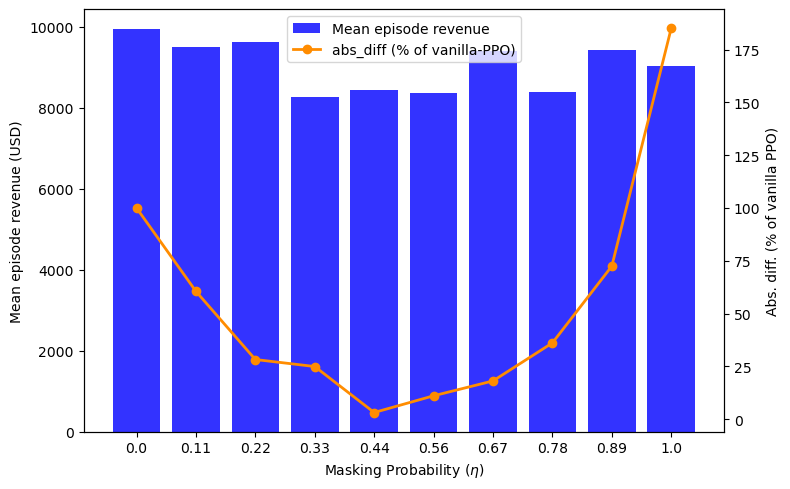

In [20]:
x = np.arange(len(experiment3_results))

fig, ax1 = plt.subplots(figsize=(8, 5))

# create barplot of mean episodic revenue
ax1.bar(x, experiment3_results["mean_episode_revenue"], color="blue", alpha=0.8, label="Mean episode revenue")

# note: x axis labels are plotted as discrete
ax1.set_xticks(x)
ax1.set_xticklabels(np.round(experiment3_results["random_sens_prob"],2))

# create dual y-axis then plot abs. diff. (as % of pure PPO)
ax2 = ax1.twinx()
ax2.plot(x,
         experiment3_results["abs_diff (% of vanilla-PPO)"],
         color="darkorange",
         marker="o",
         linewidth=2,
         label="abs_diff (% of vanilla-PPO)")

# add axis labels
ax1.set_xlabel(r"Masking Probability ($\eta$)")
ax1.set_ylabel("Mean episode revenue (USD)")
ax2.set_ylabel("Abs. diff. (% of vanilla PPO)")

# single combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center")

plt.tight_layout()
plt.savefig(FIGURES_PATH + "experiment_3_revenue_vs_absdiff.pdf", format="pdf", bbox_inches="tight")

## Plot: % of parameter = 0 in terms of revenue vs. fairness 

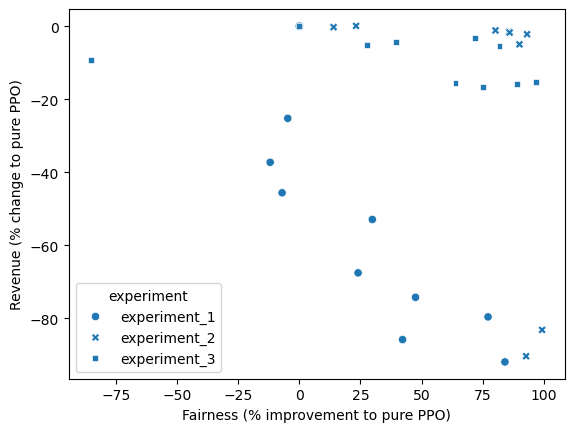

In [23]:
experiment_results = pd.concat([
    calculate_final_results_table("experiment_1"),
    calculate_final_results_table("experiment_2"),
    calculate_final_results_table("experiment_3")
], ignore_index=True)

sns.scatterplot(data=experiment_results,
            x="abs_diff_perc_fairness",
            y="abs_diff_perc_revenue",
            style="experiment")
plt.xlabel("Fairness (% improvement to pure PPO)")
plt.ylabel("Revenue (% change to pure PPO)")
plt.savefig(FIGURES_PATH + "compare_experiments.pdf", format="pdf", bbox_inches="tight")